--- [시계열 데이터 분석 요약] ---
전체 파일 수: 19956개
시작 날짜: 2011-01-01
종료 날짜: 2015-12-31
고유 날짜 수: 1313일

--- [연도별 데이터 분포] ---
year
2011     923
2012    1221
2013    3553
2014    6035
2015    8224
Name: count, dtype: int64


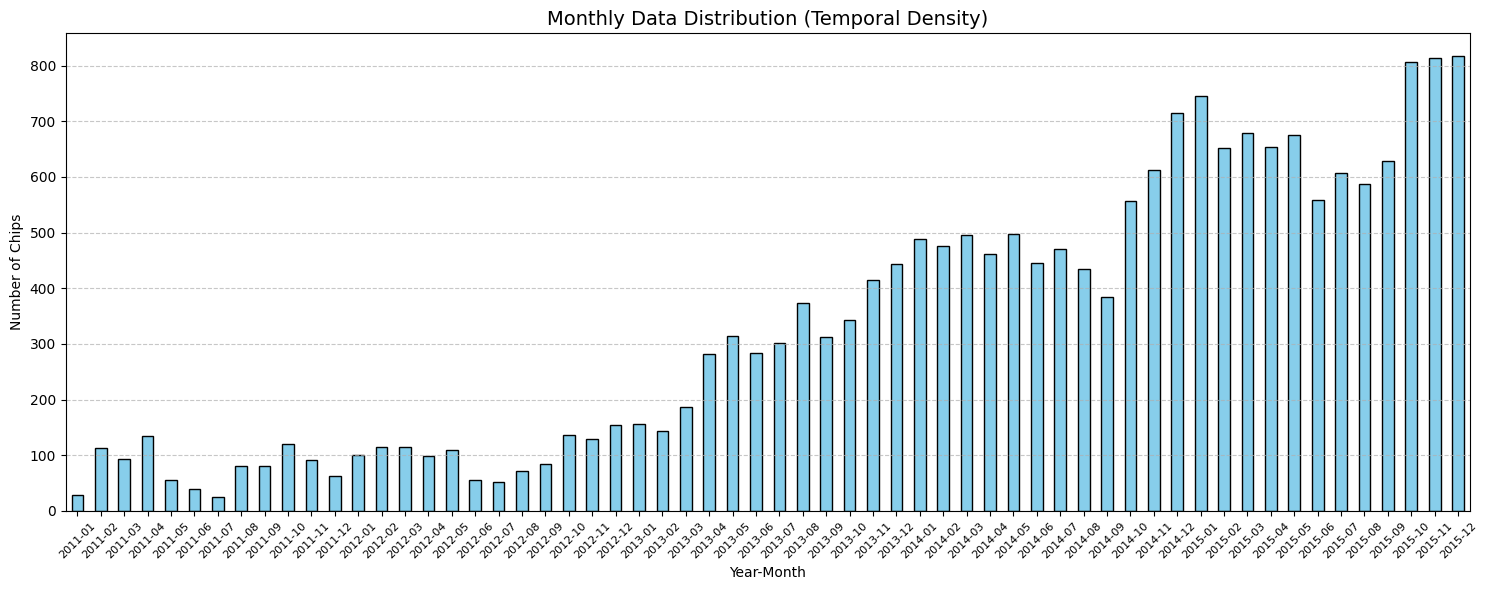

In [2]:
#다운받은 원본데이터를 분석하는 코드
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# 1. 경로 설정 (상대 경로: notebooks -> rawData/chips)
BASE_DIR = ".."
CHIP_DIR = os.path.join(BASE_DIR, "rawData", "chips")

# 2. 파일 목록에서 날짜 추출
chip_files = glob.glob(f"{CHIP_DIR}/loc_*/*.npy")

if not chip_files:
    print("❌ 데이터를 찾을 수 없습니다. 경로를 확인하세요.")
else:
    data_list = []
    for f in chip_files:
        # 파일명에서 날짜 추출 (예: 2014-06-21.npy -> 2014-06-21)
        date_str = os.path.basename(f).replace('.npy', '')
        try:
            date_obj = datetime.strptime(date_str, '%Y-%m-%d')
            data_list.append({
                'date': date_obj,
                'year': date_obj.year,
                'month': date_obj.month,
                'year_month': date_obj.strftime('%Y-%m')
            })
        except ValueError:
            continue # 날짜 형식이 아니면 건너뜀

    # 3. 데이터프레임(DataFrame) 생성
    df = pd.DataFrame(data_list)

    # 4. 통계 요약 출력
    print("--- [시계열 데이터 분석 요약] ---")
    print(f"전체 파일 수: {len(df)}개")
    print(f"시작 날짜: {df['date'].min().date()}")
    print(f"종료 날짜: {df['date'].max().date()}")
    print(f"고유 날짜 수: {df['date'].nunique()}일")
    print("\n--- [연도별 데이터 분포] ---")
    print(df['year'].value_counts().sort_index())

    # 5. 시각화 (월별 데이터 분포)
    plt.figure(figsize=(15, 6))
    df.groupby('year_month').size().plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title('Monthly Data Distribution (Temporal Density)', fontsize=14)
    plt.xlabel('Year-Month')
    plt.ylabel('Number of Chips')
    plt.xticks(rotation=45, fontsize=8)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()